# NIVEL AVANZADO - Calidad de Datos con POO

Este notebook implementa un sistema de calidad de datos del Registro Nacional de Municipalidades (RENAMU 2022) usando programación orientada a objetos.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Any
from dataclasses import dataclass
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## Clases Base del Sistema

In [28]:
@dataclass
class ResultadoCalidad:
    """
    Clase para almacenar resultados de análisis de calidad.
    
    Attributes:
        dimension (str): Nombre de la dimensión de calidad evaluada
        registros_problematicos (pd.DataFrame): DataFrame con registros que tienen problemas
        total_registros (int): Total de registros en el dataset
        descripcion (str): Descripción del problema encontrado
        severidad (str): Nivel de severidad (ALTA, MEDIA, BAJA)
    """
    dimension: str
    registros_problematicos: pd.DataFrame
    total_registros: int
    descripcion: str = ""
    severidad: str = "MEDIA"
    
    @property
    def cantidad_problemas(self) -> int:
        """Retorna la cantidad de registros con problemas"""
        return len(self.registros_problematicos)
    
    @property
    def porcentaje_afectado(self) -> float:
        """Calcula el porcentaje de registros afectados"""
        if self.total_registros == 0:
            return 0.0
        return (self.cantidad_problemas / self.total_registros) * 100
    
    def resumen(self) -> Dict[str, Any]:
        """
        Genera un resumen del resultado.
        
        Returns:
            dict: Diccionario con métricas clave
        """
        return {
            'dimensión': self.dimension,
            'problemas': self.cantidad_problemas,
            'porcentaje': round(self.porcentaje_afectado, 2),
            'severidad': self.severidad
        }

In [29]:
class AnalizadorCalidadBase:
    """
    Clase base abstracta para analizadores de calidad de datos.
    
    Esta clase define la interfaz que deben implementar todos los analizadores
    de dimensiones específicas de calidad.
    
    Attributes:
        df (pd.DataFrame): DataFrame a analizar
        nombre_dimension (str): Nombre de la dimensión de calidad
    """
    
    def __init__(self, df: pd.DataFrame, nombre_dimension: str):
        """
        Inicializa el analizador.
        
        Args:
            df: DataFrame de pandas con los datos a analizar
            nombre_dimension: Nombre identificador de la dimensión
        """
        self.df = df
        self.nombre_dimension = nombre_dimension
        self.resultados = []
    
    def analizar(self) -> List[ResultadoCalidad]:
        """
        Método abstracto que debe implementar cada analizador.
        
        Returns:
            Lista de ResultadoCalidad con los problemas encontrados
        """
        raise NotImplementedError("Subclases deben implementar este método")
    
    def _crear_resultado(self, registros: pd.DataFrame, descripcion: str, 
                        severidad: str = "MEDIA") -> ResultadoCalidad:
        """
        Crea un objeto ResultadoCalidad.
        
        Args:
            registros: DataFrame con registros problemáticos
            descripcion: Descripción del problema
            severidad: Nivel de severidad del problema
        
        Returns:
            Objeto ResultadoCalidad configurado
        """
        return ResultadoCalidad(
            dimension=self.nombre_dimension,
            registros_problematicos=registros,
            total_registros=len(self.df),
            descripcion=descripcion,
            severidad=severidad
        )

## Analizadores Específicos por Dimensión

In [30]:
class AnalizadorCompletitud(AnalizadorCalidadBase):
    """
    Analiza la completitud de los datos (valores faltantes).
    
    La completitud mide si todos los campos requeridos tienen valores.
    Identifica columnas con valores NULL o vacíos.
    """
    
    def __init__(self, df: pd.DataFrame, max_columnas_reportadas: int = 20):
        super().__init__(df, "Completitud")
        self.max_columnas_reportadas = max_columnas_reportadas
    
    def analizar(self) -> List[ResultadoCalidad]:
        """
        Ejecuta el análisis de completitud.
        
        Identifica columnas con valores faltantes y crea resultados para
        las columnas más afectadas, de modo que el reporte sea manejable
        en un dataset amplio como RENAMU 2022.
        
        Returns:
            Lista de ResultadoCalidad para las columnas con más faltantes
        """
        resultados = []
        faltantes_por_columna = self.df.isnull().sum().sort_values(ascending=False)
        columnas_con_faltantes = faltantes_por_columna[faltantes_por_columna > 0].head(self.max_columnas_reportadas)
        
        for columna, cantidad in columnas_con_faltantes.items():
            faltantes = self.df[self.df[columna].isnull()]
            severidad = self._determinar_severidad(int(cantidad))
            resultado = self._crear_resultado(
                registros=faltantes,
                descripcion=f"Valores faltantes en columna '{columna}'",
                severidad=severidad
            )
            resultados.append(resultado)
        
        return resultados
    
    def _determinar_severidad(self, cantidad: int) -> str:
        """
        Determina la severidad basándose en la cantidad de faltantes.
        
        Args:
            cantidad: Número de registros faltantes
        
        Returns:
            'ALTA', 'MEDIA' o 'BAJA'
        """
        porcentaje = (cantidad / len(self.df)) * 100
        if porcentaje > 10:
            return "ALTA"
        elif porcentaje > 5:
            return "MEDIA"
        return "BAJA"

In [31]:
def normalizar_codigo(serie: pd.Series, ancho: int) -> pd.Series:
    """Normaliza códigos geográficos conservando ceros a la izquierda"""
    return (
        serie.astype(str)
        .str.strip()
        .str.replace(r'\.0$', '', regex=True)
        .str.zfill(ancho)
    )

class AnalizadorExactitud(AnalizadorCalidadBase):
    """
    Analiza la exactitud de códigos geográficos y catálogos básicos.
    
    Detecta valores incorrectos en Ubigeo, códigos INEI, tipo de
    municipalidad y año del registro RENAMU 2022.
    """
    
    def __init__(self, df: pd.DataFrame):
        super().__init__(df, "Exactitud")
    
    def analizar(self) -> List[ResultadoCalidad]:
        """
        Ejecuta validaciones de exactitud para RENAMU 2022.
        
        Verifica:
        - Ubigeo con longitud de 6 dígitos
        - Ubigeo compuesto solo por números
        - Códigos ccdd, ccpp y ccdi en rangos esperados
        - Tipomuni dentro del catálogo 1-2
        - Año igual a 2022
        
        Returns:
            Lista de ResultadoCalidad con los problemas detectados
        """
        resultados = []
        df_trabajo = self._preparar_df()
        ubigeo_str = df_trabajo['ubigeo_normalizado']
        
        # Ubigeo con longitud inválida
        ubigeo_longitud = df_trabajo[ubigeo_str.str.len() != 6]
        if len(ubigeo_longitud) > 0:
            resultados.append(self._crear_resultado(
                ubigeo_longitud, "Ubigeos con longitud distinta a 6 dígitos", "ALTA"
            ))
        
        # Ubigeo no numérico
        ubigeo_no_numerico = df_trabajo[~ubigeo_str.str.match(r'^\d{6}$', na=False)]
        if len(ubigeo_no_numerico) > 0:
            resultados.append(self._crear_resultado(
                ubigeo_no_numerico, "Ubigeos con caracteres no numéricos", "ALTA"
            ))
        
        # Códigos territoriales fuera de rango
        reglas_rango = {
            'ccdd': (1, 25),
            'ccpp': (1, 99),
            'ccdi': (1, 99)
        }
        for columna, (minimo, maximo) in reglas_rango.items():
            invalidos = df_trabajo[
                df_trabajo[columna].isna() |
                (df_trabajo[columna] < minimo) |
                (df_trabajo[columna] > maximo)
            ]
            if len(invalidos) > 0:
                resultados.append(self._crear_resultado(
                    invalidos,
                    f"{columna} fuera del rango esperado {minimo}-{maximo}",
                    "ALTA"
                ))
        
        # Tipo de municipalidad fuera del catálogo
        tipomuni_invalidos = df_trabajo[~df_trabajo['Tipomuni'].isin([1, 2])]
        if len(tipomuni_invalidos) > 0:
            resultados.append(self._crear_resultado(
                tipomuni_invalidos, "Tipomuni fuera del catálogo válido (1=provincial, 2=distrital)", "ALTA"
            ))
        
        # Año distinto al periodo esperado
        anio_invalido = df_trabajo[df_trabajo['Año'] != 2022]
        if len(anio_invalido) > 0:
            resultados.append(self._crear_resultado(
                anio_invalido, "Registros con Año distinto a 2022", "MEDIA"
            ))
        
        return resultados
    
    def _preparar_df(self) -> pd.DataFrame:
        """Crea columnas auxiliares para validaciones de exactitud"""
        df_trabajo = self.df.copy()
        for columna in ['Año', 'ccdd', 'ccpp', 'ccdi', 'Tipomuni']:
            df_trabajo[columna] = pd.to_numeric(df_trabajo[columna], errors='coerce')
        df_trabajo['ubigeo_normalizado'] = normalizar_codigo(df_trabajo['Ubigeo'], 6)
        return df_trabajo

class AnalizadorConsistencia(AnalizadorCalidadBase):
    """
    Analiza la consistencia entre campos relacionados.
    
    Verifica que el Ubigeo coincida con la concatenación de ccdd, ccpp y ccdi,
    y que el tipo de municipalidad sea coherente con el código distrital.
    """
    
    def __init__(self, df: pd.DataFrame):
        super().__init__(df, "Consistencia")
    
    def analizar(self) -> List[ResultadoCalidad]:
        resultados = []
        df_trabajo = self._preparar_df()
        
        inconsistencias_ubigeo = df_trabajo[
            df_trabajo['ubigeo_normalizado'] != df_trabajo['ubigeo_esperado']
        ]
        if len(inconsistencias_ubigeo) > 0:
            resultados.append(self._crear_resultado(
                inconsistencias_ubigeo, "Ubigeo no coincide con ccdd + ccpp + ccdi", "ALTA"
            ))
        
        tipomuni_inconsistente = df_trabajo[
            df_trabajo['Tipomuni'] != df_trabajo['tipomuni_esperado']
        ]
        if len(tipomuni_inconsistente) > 0:
            resultados.append(self._crear_resultado(
                tipomuni_inconsistente, "Tipomuni no es coherente con el código distrital", "MEDIA"
            ))
        
        return resultados
    
    def _preparar_df(self) -> pd.DataFrame:
        """Prepara columnas esperadas para validaciones de consistencia"""
        df_trabajo = self.df.copy()
        for columna in ['ccdd', 'ccpp', 'ccdi', 'Tipomuni']:
            df_trabajo[columna] = pd.to_numeric(df_trabajo[columna], errors='coerce')
        df_trabajo['ubigeo_normalizado'] = normalizar_codigo(df_trabajo['Ubigeo'], 6)
        ccdd_str = df_trabajo['ccdd'].astype('Int64').astype(str).str.zfill(2)
        ccpp_str = df_trabajo['ccpp'].astype('Int64').astype(str).str.zfill(2)
        ccdi_str = df_trabajo['ccdi'].astype('Int64').astype(str).str.zfill(2)
        df_trabajo['ubigeo_esperado'] = ccdd_str + ccpp_str + ccdi_str
        df_trabajo['tipomuni_esperado'] = np.where(df_trabajo['ccdi'] == 1, 1, 2)
        return df_trabajo

class AnalizadorIntegridad(AnalizadorCalidadBase):
    """
    Analiza integridad de identificadores municipales y geográficos.
    
    Detecta identificadores vacíos, mal formados o duplicados.
    """
    
    def __init__(self, df: pd.DataFrame):
        super().__init__(df, "Integridad")
    
    def analizar(self) -> List[ResultadoCalidad]:
        resultados = []
        df_trabajo = self.df.copy()
        df_trabajo['idmunici_normalizado'] = normalizar_codigo(df_trabajo['idmunici'], 6)
        df_trabajo['ubigeo_normalizado'] = normalizar_codigo(df_trabajo['Ubigeo'], 6)
        
        ids_invalidos = df_trabajo[
            df_trabajo['idmunici'].isna() |
            ~df_trabajo['idmunici_normalizado'].str.match(r'^\d{6}$', na=False)
        ]
        if len(ids_invalidos) > 0:
            resultados.append(self._crear_resultado(
                ids_invalidos, "Identificadores municipales vacíos o mal formados", "ALTA"
            ))
        
        ids_duplicados = df_trabajo[df_trabajo.duplicated(subset=['idmunici_normalizado'], keep=False)]
        if len(ids_duplicados) > 0:
            resultados.append(self._crear_resultado(
                ids_duplicados, "Identificadores municipales duplicados", "ALTA"
            ))
        
        ubigeos_duplicados = df_trabajo[df_trabajo.duplicated(subset=['ubigeo_normalizado'], keep=False)]
        if len(ubigeos_duplicados) > 0:
            resultados.append(self._crear_resultado(
                ubigeos_duplicados, "Ubigeos duplicados", "ALTA"
            ))
        
        return resultados

class AnalizadorRazonabilidad(AnalizadorCalidadBase):
    """
    Analiza valores fuera de rangos razonables.
    
    Revisa códigos territoriales y valores negativos en variables numéricas
    que, por tratarse de conteos o montos reportados, no deberían ser negativos.
    """
    
    def __init__(self, df: pd.DataFrame):
        super().__init__(df, "Razonabilidad")
    
    def analizar(self) -> List[ResultadoCalidad]:
        resultados = []
        df_trabajo = self.df.copy()
        for columna in ['Año', 'ccdd', 'ccpp', 'ccdi', 'Tipomuni']:
            df_trabajo[columna] = pd.to_numeric(df_trabajo[columna], errors='coerce')
        
        codigos_fuera_rango = df_trabajo[
            (df_trabajo['ccdd'] < 1) | (df_trabajo['ccdd'] > 25) |
            (df_trabajo['ccpp'] < 1) | (df_trabajo['ccpp'] > 99) |
            (df_trabajo['ccdi'] < 1) | (df_trabajo['ccdi'] > 99)
        ]
        if len(codigos_fuera_rango) > 0:
            resultados.append(self._crear_resultado(
                codigos_fuera_rango, "Códigos territoriales fuera de rangos razonables", "ALTA"
            ))
        
        columnas_numericas = df_trabajo.select_dtypes(include=[np.number]).columns.tolist()
        columnas_excluidas = ['Año', 'idmunici', 'ccdd', 'ccpp', 'ccdi', 'Ubigeo', 'Tipomuni']
        columnas_indicadores = [col for col in columnas_numericas if col not in columnas_excluidas]
        mascara_negativos = df_trabajo[columnas_indicadores].lt(0).any(axis=1) if columnas_indicadores else pd.Series(False, index=df_trabajo.index)
        negativos = df_trabajo[mascara_negativos]
        if len(negativos) > 0:
            resultados.append(self._crear_resultado(
                negativos, "Registros con valores negativos en indicadores numéricos", "MEDIA"
            ))
        
        return resultados

class AnalizadorOportunidad(AnalizadorCalidadBase):
    """
    Analiza la oportunidad temporal del registro.
    
    Valida que los datos correspondan al periodo esperado del RENAMU 2022.
    """
    
    def __init__(self, df: pd.DataFrame, anio_esperado: int = 2022):
        super().__init__(df, "Oportunidad")
        self.anio_esperado = anio_esperado
    
    def analizar(self) -> List[ResultadoCalidad]:
        resultados = []
        df_trabajo = self.df.copy()
        df_trabajo['Año'] = pd.to_numeric(df_trabajo['Año'], errors='coerce')
        
        anios_invalidos = df_trabajo[df_trabajo['Año'] != self.anio_esperado]
        if len(anios_invalidos) > 0:
            resultados.append(self._crear_resultado(
                anios_invalidos, f"Registros que no corresponden al año {self.anio_esperado}", "MEDIA"
            ))
        
        return resultados

class AnalizadorUnicidad(AnalizadorCalidadBase):
    """
    Analiza duplicidad de registros.
    
    Detecta duplicados exactos y duplicados por Ubigeo normalizado.
    """
    
    def __init__(self, df: pd.DataFrame):
        super().__init__(df, "Unicidad")
    
    def analizar(self) -> List[ResultadoCalidad]:
        resultados = []
        df_trabajo = self.df.copy()
        df_trabajo['ubigeo_normalizado'] = normalizar_codigo(df_trabajo['Ubigeo'], 6)
        
        columnas_clave = [col for col in ['Año', 'idmunici', 'Ubigeo', 'Departamento', 'Provincia', 'Distrito', 'Tipomuni'] if col in df_trabajo.columns]
        duplicados_exactos = df_trabajo[df_trabajo.duplicated(subset=columnas_clave, keep=False)]
        if len(duplicados_exactos) > 0:
            resultados.append(self._crear_resultado(
                duplicados_exactos, "Registros duplicados en columnas clave del RENAMU", "MEDIA"
            ))
        
        duplicados_ubigeo = df_trabajo[df_trabajo.duplicated(subset=['ubigeo_normalizado'], keep=False)]
        if len(duplicados_ubigeo) > 0:
            resultados.append(self._crear_resultado(
                duplicados_ubigeo, "Registros duplicados por Ubigeo", "ALTA"
            ))
        
        return resultados

class AnalizadorValidez(AnalizadorCalidadBase):
    """
    Analiza formatos válidos de campos principales.
    
    Valida nombres geográficos y catálogos básicos del RENAMU 2022.
    """
    
    def __init__(self, df: pd.DataFrame):
        super().__init__(df, "Validez")
    
    def analizar(self) -> List[ResultadoCalidad]:
        resultados = []
        df_trabajo = self.df.copy()
        
        patron_nombre = r'^[A-ZÁÉÍÓÚÜÑ0-9 .º°()/-]+$'
        campos_texto = ['Departamento', 'Provincia', 'Distrito']
        validacion_texto = pd.DataFrame(index=df_trabajo.index)
        for columna in campos_texto:
            validacion_texto[columna] = (
                df_trabajo[columna]
                .fillna('')
                .astype(str)
                .str.strip()
                .str.match(patron_nombre, na=False)
            )
        
        nombres_invalidos = df_trabajo[~validacion_texto.all(axis=1)]
        if len(nombres_invalidos) > 0:
            resultados.append(self._crear_resultado(
                nombres_invalidos, "Nombres geográficos con formato no válido", "BAJA"
            ))
        
        tipomuni_invalidos = df_trabajo[~pd.to_numeric(df_trabajo['Tipomuni'], errors='coerce').isin([1, 2])]
        if len(tipomuni_invalidos) > 0:
            resultados.append(self._crear_resultado(
                tipomuni_invalidos, "Tipomuni fuera del catálogo válido", "ALTA"
            ))
        
        return resultados

In [32]:
class GestorCalidadDatos:
    """
    Clase principal que coordina todos los análisis de calidad.
    
    Esta clase actúa como fachada para ejecutar y consolidar
    los resultados de todos los analizadores de dimensiones.
    
    Attributes:
        df (pd.DataFrame): Dataset a analizar
        analizadores (List): Lista de analizadores configurados
        resultados_globales (Dict): Resultados consolidados de todos los análisis
    """
    
    def __init__(self, df: pd.DataFrame):
        """
        Inicializa el gestor con el dataset.
        
        Args:
            df: DataFrame de pandas con los datos a analizar
        """
        self.df = df
        self.analizadores = []
        self.resultados_globales = {}
    
    def registrar_analizador(self, analizador: AnalizadorCalidadBase) -> None:
        """
        Registra un nuevo analizador en el sistema.
        
        Args:
            analizador: Instancia de un analizador de calidad
        """
        self.analizadores.append(analizador)
    
    def ejecutar_analisis_completo(self) -> Dict[str, List[ResultadoCalidad]]:
        """
        Ejecuta todos los analizadores registrados.
        
        Itera sobre cada analizador, ejecuta su análisis y almacena
        los resultados organizados por dimensión.
        
        Returns:
            Diccionario con resultados agrupados por dimensión
        """
        for analizador in self.analizadores:
            dimension = analizador.nombre_dimension
            resultados = analizador.analizar()
            self.resultados_globales[dimension] = resultados
        
        return self.resultados_globales
    
    def generar_reporte_consolidado(self) -> pd.DataFrame:
        """
        Genera un reporte consolidado de todas las dimensiones.
        
        Agrupa los resultados de todos los analizadores en un
        DataFrame con métricas resumen.
        
        Returns:
            DataFrame con resumen ejecutivo de calidad
        """
        datos_reporte = []
        
        for dimension, resultados in self.resultados_globales.items():
            total_problemas = sum(r.cantidad_problemas for r in resultados)
            porcentaje = (total_problemas / len(self.df)) * 100 if len(self.df) > 0 else 0
            
            datos_reporte.append({
                'Dimensión': dimension,
                'Registros Afectados': total_problemas,
                'Porcentaje': round(porcentaje, 2),
                'Tipos de Problemas': len(resultados)
            })
        
        return pd.DataFrame(datos_reporte)
    
    def visualizar_resultados(self) -> None:
        """
        Genera visualizaciones de los resultados de calidad.
        
        Crea gráficos de barras mostrando el porcentaje de registros
        afectados por dimensión.
        """
        reporte = self.generar_reporte_consolidado()
        
        plt.figure(figsize=(12, 6))
        plt.barh(reporte['Dimensión'], reporte['Porcentaje'], color='steelblue')
        plt.xlabel('Porcentaje de Registros Afectados (%)', fontsize=12)
        plt.title('Problemas de Calidad por Dimensión', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

## Ejecución del Sistema de Calidad

In [33]:
# Cargar datos
# Nota: el RENAMU usa separador punto y coma (;) y encoding utf-8-sig
# para conservar correctamente caracteres como Año y Nº.
df = pd.read_csv(
    'Base_RENAMU_2022_f.csv',
    sep=';',
    encoding='utf-8-sig',
    low_memory=False
)

# Limpiar nombres de columnas y valores vacíos
df.columns = df.columns.str.strip()
df = df.rename(columns={df.columns[0]: 'Año'})
df = df.replace(r'^\s*$', np.nan, regex=True)

print(f"Dataset cargado: {len(df):,} registros")
print(f"Total de columnas: {df.shape[1]:,}")

# Crear gestor principal
gestor = GestorCalidadDatos(df)

# Registrar analizadores
gestor.registrar_analizador(AnalizadorCompletitud(df))
gestor.registrar_analizador(AnalizadorExactitud(df))
gestor.registrar_analizador(AnalizadorConsistencia(df))
gestor.registrar_analizador(AnalizadorIntegridad(df))
gestor.registrar_analizador(AnalizadorRazonabilidad(df))
gestor.registrar_analizador(AnalizadorOportunidad(df))
gestor.registrar_analizador(AnalizadorUnicidad(df))
gestor.registrar_analizador(AnalizadorValidez(df))


Dataset cargado: 508,000 registros


In [34]:
# Ejecutar análisis completo
resultados = gestor.ejecutar_analisis_completo()
print("Análisis completado")

# Mostrar resultados detallados
for dimension, lista_resultados in resultados.items():
    print(f"DIMENSIÓN: {dimension}")
    for resultado in lista_resultados:
        print(f"  • {resultado.descripcion}")
        print(f"    Registros: {resultado.cantidad_problemas:,} ({resultado.porcentaje_afectado:.2f}%)")
        print(f"    Severidad: {resultado.severidad}")
        print()

Análisis completado
DIMENSIÓN: Completitud
  • Valores faltantes en columna 'cliente_email'
    Registros: 3,043 (0.60%)
    Severidad: BAJA

  • Valores faltantes en columna 'metodo_pago'
    Registros: 3,044 (0.60%)
    Severidad: BAJA

  • Valores faltantes en columna 'region'
    Registros: 4,067 (0.80%)
    Severidad: BAJA

DIMENSIÓN: Exactitud
  • Precios unitarios negativos
    Registros: 1,020 (0.20%)
    Severidad: ALTA

  • Precios unitarios en cero
    Registros: 1,015 (0.20%)
    Severidad: ALTA

  • Descuentos mayores al 100%
    Registros: 1,518 (0.30%)
    Severidad: ALTA



REPORTE CONSOLIDADO DE CALIDAD
  Dimensión  Registros Afectados  Porcentaje  Tipos de Problemas
Completitud                10154         2.0                   3
  Exactitud                 3553         0.7                   3


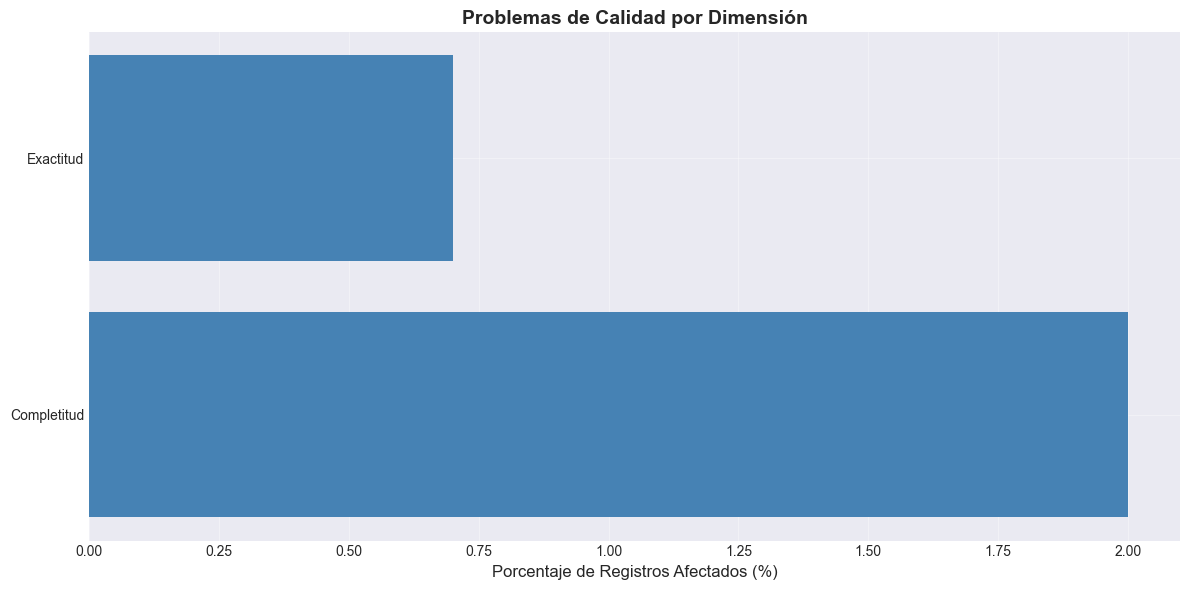

In [35]:
# Generar reporte consolidado
reporte = gestor.generar_reporte_consolidado()

print("REPORTE CONSOLIDADO DE CALIDAD")
print(reporte.to_string(index=False))

# Visualizar resultados
gestor.visualizar_resultados()

## Análisis Detallado por Dimensión

El sistema permite acceder a los registros problemáticos específicos:

In [36]:
# Ejemplo: Ver registros con problemas de exactitud
columnas_muestra = [
    'Año', 'idmunici', 'ccdd', 'ccpp', 'ccdi',
    'Ubigeo', 'Departamento', 'Provincia', 'Distrito', 'Tipomuni'
]
columnas_muestra = [col for col in columnas_muestra if col in df.columns]

if 'Exactitud' in resultados:
    print("Ejemplos de problemas de EXACTITUD:\n")
    if len(resultados['Exactitud']) == 0:
        print("No se detectaron problemas de exactitud con las reglas configuradas.")
    else:
        for resultado in resultados['Exactitud']:
            print(f"\n{resultado.descripcion}:")
            print(resultado.registros_problematicos.head()[columnas_muestra])


Ejemplos de problemas de EXACTITUD:


Precios unitarios negativos:
      id_transaccion producto  precio_unitario  descuento
167             1168      RAM       -52.696179       0.18
174             1175    Mouse      -483.605129       0.15
543             1544  Teclado      -154.421181       0.27
1057            2058      SSD       -70.007138       0.14
2139            3140      RAM      -243.477752       0.26

Precios unitarios en cero:
      id_transaccion   producto  precio_unitario  descuento
21              1022    Monitor              0.0       0.05
633             1634        SSD              0.0       0.17
894             1895  Audífonos              0.0       0.03
1102            2103      Mouse              0.0       0.03
1245            2246     Laptop              0.0       0.29

Descuentos mayores al 100%:
      id_transaccion producto  precio_unitario  descuento
67              1068  Teclado            47.43   2.010769
1141            2142   Webcam            34.56   1.5